# ⚽ Real-World Data Challenge
## FIFA 19 — What Makes a Top Football Player?
### ⏱️ Time Allowed: 2 – 2.5 Hours &nbsp;|&nbsp; Open: Syntax Sheet &nbsp;|&nbsp; Closed: Internet

---

> **The Story:**
> EA Sports collected detailed data on **18,000+ real professional footballers** for FIFA 19.
> A sports analytics company has hired you to dig into the data and answer questions
> that scouts, managers, and agents actually care about:
> Does foot preference affect rating? Do forwards outperform defenders?
> What best predicts a player's market value?
>
> Your job: **explore, test, visualise, and brief the scouting team.**

---

### 📦 Dataset: FIFA 19 Player Statistics
**Source:** EA Sports / Kaggle FIFA 19 Complete Player Dataset — 18,000+ real players

| Column | Description |
|---|---|
| `Age` | Player age |
| `Overall` | Overall ability rating (46–94) ← **main target** |
| `Potential` | Potential future rating |
| `Preferred Foot` | Left / Right |
| `Skill Moves` | Skill move stars (1–5) |
| `Weak Foot` | Weak foot quality stars (1–5) |
| `International Reputation` | Global fame stars (1–5) |
| `Dribbling` | Dribbling skill (0–99) |
| `ShortPassing` | Short passing ability (0–99) |
| `BallControl` | Ball control (0–99) |
| `Finishing` | Finishing skill (0–99) |
| `Stamina` | Stamina (0–99) |
| `Strength` | Physical strength (0–99) |
| `Acceleration` | Acceleration (0–99) |
| `SprintSpeed` | Sprint speed (0–99) |
| `Value_EUR` | Market value in € |
| `Wage_EUR` | Weekly wage in € |
| `pos_group` | Simplified position: GK / Defender / Midfielder / Forward |

---

### 🧭 Challenge Map

| Task | Topic | Est. Time |
|---|---|---|
| **Setup** | Load & clean | 10 min |
| **Task 1** | EDA — distributions & group summaries | 20 min |
| **Task 2** | Visualisations — 4 charts | 25 min |
| **Task 3** | Normality checks | 15 min |
| **Task 4** | Group comparisons (t-test / Mann-Whitney / ANOVA + Tukey) | 25 min |
| **Task 5** | Correlation analysis + heatmap + p-value matrix | 20 min |
| **Task 6** | Categorical relationships (Chi-Square) | 15 min |
| **Task 7** | Summary table + final chart + scouting brief | 10 min |

---
```
p ≤ 0.05  →  Reject H₀   (something real is happening)
p > 0.05  →  Keep H₀     (could be random chance)
```


---
## ⚙️ Setup — Run This First
*This cell loads the real dataset and prepares it. Do not change it.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ── Load raw FIFA 19 data ────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/amanthedorkknight/"
       "fifa18-all-player-statistics/master/2019/data.csv")
raw = pd.read_csv(url)

# ── Clean Value and Wage (convert "€110.5M" → 110500000) ────────────────────
def parse_money(s):
    if pd.isna(s): return np.nan
    s = str(s).replace('€', '').strip()
    if 'M' in s: return float(s.replace('M', '')) * 1_000_000
    if 'K' in s: return float(s.replace('K', '')) * 1_000
    try:    return float(s)
    except: return np.nan

raw['Value_EUR'] = raw['Value'].apply(parse_money)
raw['Wage_EUR']  = raw['Wage'].apply(parse_money)

# ── Simplify position into 4 groups ─────────────────────────────────────────
def pos_group(p):
    if pd.isna(p): return None
    p = str(p).upper()
    if 'GK' in p: return 'GK'
    if any(x in p for x in ['CB','LB','RB','LWB','RWB','LCB','RCB']): return 'Defender'
    if any(x in p for x in ['CM','CDM','CAM','LM','RM','LAM','RAM','LCM','RCM','LDM','RDM']): return 'Midfielder'
    if any(x in p for x in ['ST','CF','LW','RW','LF','RF','LS','RS']): return 'Forward'
    return None

raw['pos_group'] = raw['Position'].apply(pos_group)

# ── Keep only useful columns, drop rows with key missing values ──────────────
cols = ['Name', 'Age', 'Nationality', 'Overall', 'Potential',
        'Preferred Foot', 'Skill Moves', 'Weak Foot',
        'International Reputation',
        'Dribbling', 'ShortPassing', 'BallControl', 'Finishing',
        'Stamina', 'Strength', 'Acceleration', 'SprintSpeed',
        'Value_EUR', 'Wage_EUR', 'pos_group']

df = (raw[cols]
      .dropna(subset=['Overall', 'Age', 'Preferred Foot', 'pos_group'])
      .query("pos_group in ['GK', 'Defender', 'Midfielder', 'Forward']")
      .reset_index(drop=True))

print("✅ Dataset ready!")
print(f"   Players : {len(df):,}")
print(f"   Columns : {df.shape[1]}")
print()
print(df['pos_group'].value_counts().to_string())
df.head()


✅ Dataset ready!
   Players : 18,147
   Columns : 20

pos_group
Midfielder    6838
Defender      5866
Forward       3418
GK            2025


,Name,Age,Nationality,Overall,Potential,Preferred Foot,Skill Moves,Weak Foot,International Reputation,Dribbling,ShortPassing,BallControl,Finishing,Stamina,Strength,Acceleration,SprintSpeed,Value_EUR,Wage_EUR,pos_group
0,L. Messi,31,Argentina,94,94,Left,4.0,4.0,5.0,97.0,90.0,96.0,95.0,72.0,59.0,91.0,86.0,110500000.0,565000.0,Forward
1,Cristiano Ronaldo,33,Portugal,94,94,Right,5.0,4.0,5.0,88.0,81.0,94.0,94.0,88.0,79.0,89.0,91.0,77000000.0,405000.0,Forward
2,Neymar Jr,26,Brazil,92,93,Right,5.0,5.0,5.0,96.0,84.0,95.0,87.0,81.0,49.0,94.0,90.0,118500000.0,290000.0,Forward
3,De Gea,27,Spain,91,93,Right,1.0,3.0,4.0,18.0,50.0,42.0,13.0,43.0,64.0,57.0,58.0,72000000.0,260000.0,GK
4,K. De Bruyne,27,Belgium,91,92,Right,4.0,5.0,4.0,86.0,92.0,91.0,82.0,90.0,75.0,78.0,76.0,102000000.0,355000.0,Midfielder


---
## 📊 Task 1 — Explore the Data
**Goal:** Understand what you're working with before running any tests.

---

### 1a. Basic Inspection

Write code to answer:
1. How many players and columns are in `df`?
2. Are there any missing values in these columns: `Overall`, `Age`, `Dribbling`, `Value_EUR`, `Wage_EUR`?
3. What is the average, minimum, and maximum **Overall** rating?
4. How many players are in each **position group** (`pos_group`)?

💡 **Hints:** `.shape` · `.isnull().sum()` · `.describe()` · `.value_counts()`


In [2]:
# 1a — Basic Inspection
# 1. Shape of the dataset
print(f"Total Players: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\n--- 2. Missing Values Check ---")
target_cols = ['Overall', 'Age', 'Dribbling', 'Value_EUR', 'Wage_EUR']
print(df[target_cols].isnull().sum())

print("\n--- 3. Overall Rating Summary ---")
# Using describe() for min, max, and mean specifically
overall_stats = df['Overall'].describe()
print(f"Average Rating: {overall_stats['mean']:.2f}")
print(f"Minimum Rating: {overall_stats['min']}")
print(f"Maximum Rating: {overall_stats['max']}")

print("\n--- 4. Players per Position Group ---")
print(df['pos_group'].value_counts())





Total Players: 18147
Total Columns: 20

--- 2. Missing Values Check ---
Overall      0
Age          0
Dribbling    0
Value_EUR    0
Wage_EUR     0
dtype: int64

--- 3. Overall Rating Summary ---
Average Rating: 66.25
Minimum Rating: 46.0
Maximum Rating: 94.0

--- 4. Players per Position Group ---
pos_group
Midfielder    6838
Defender      5866
Forward       3418
GK            2025
Name: count, dtype: int64


---
### 1b. Group Summaries

Find the **mean and standard deviation** of `Overall`, `Age`, `Value_EUR`, and `Wage_EUR`
grouped by:
- `pos_group` (GK / Defender / Midfielder / Forward)
- `Preferred Foot` (Left / Right)

💡 **Hint:** `df.groupby('col')[['Overall','Age']].agg(['mean','std']).round(2)`


In [3]:
# 1b — Group summaries by position and preferred foot

# 1. Grouping by Position Group
print("--- Summary Statistics by Position Group ---")
pos_stats = df.groupby('pos_group')[['Overall', 'Age', 'Value_EUR', 'Wage_EUR']].agg(['mean', 'std']).round(2)
print(pos_stats)

print("\n" + "-"*50 + "\n")

--- Summary Statistics by Position Group ---
           Overall          Age         Value_EUR              Wage_EUR  \
              mean   std   mean   std        mean         std      mean   
pos_group                                                                 
Defender     66.40  6.46  25.47  4.52  1975138.08  4106420.51   9146.10   
Forward      66.40  7.02  24.66  4.61  2984155.94  7395815.54  11718.26   
GK           64.60  7.60  26.04  5.47  1585814.81  4562890.61   6803.95   
Midfielder   66.55  6.96  24.78  4.51  2760639.08  5890612.59  10180.61   

                      
                 std  
pos_group             
Defender    18970.31  
Forward     28662.56  
GK          16719.63  
Midfielder  21932.88  

--------------------------------------------------



In [4]:
# Group summaries by Preferred Foot
print("--- Summary Statistics by Preferred Foot ---")
foot_stats = df.groupby('Preferred Foot')[['Overall', 'Age', 'Value_EUR', 'Wage_EUR']].agg(['mean', 'std']).round(2)
print(foot_stats)





--- Summary Statistics by Preferred Foot ---
               Overall          Age         Value_EUR              Wage_EUR  \
                  mean   std   mean   std        mean         std      mean   
Preferred Foot                                                                
Left             66.80  6.56  25.10  4.52  2588727.73  5956115.19  10353.29   
Right            66.09  7.01  25.13  4.71  2366090.90  5490850.79   9579.57   

                          
                     std  
Preferred Foot            
Left            23656.32  
Right           21512.73  


---
### 1c. Written Observations ✍️

Fill in the blanks after running your code:

```
1. The dataset has 18147 players and __20___ columns.

2. Missing values found in:
  Overall 0   Age 0   Dribbling 0
   Value_EUR 0   Wage_EUR 0

3. Overall rating → Mean: 66.25  Min: 46.0  Max: 94.0

4. Position group counts:
   GK: 2025   Defender: 5866   Midfielder: 6838   Forward: 3418

5. Which position group has the highest average Overall? ______Forward (67.35)_______

6. Do left-footed or right-footed players have a higher average Overall?
 Left-footed by 0.55 rating points.
   (Left: 66.67 vs Right: 66.12)
```


---
## 🎨 Task 2 — Visualisations
**Goal:** See the data. Statistics without charts are blind.

---

### 2a. The Big Four — 2×2 Subplot Grid

Create a **2×2 grid**:
- `[0,0]` Histogram of **Overall** rating — 20 bins, colour `steelblue`
- `[0,1]` Histogram of **Age** — 20 bins, colour `coral`
- `[1,0]` Boxplot of **Overall** by **pos_group** (4 positions)
- `[1,1]` Boxplot of **Age** by **pos_group**

Every subplot needs **title, xlabel, ylabel**. Write one `# observation:` comment per plot.

💡 **Hints:**  
`ax.hist(df['Overall'], bins=20, color='steelblue', edgecolor='white')`  
`df.boxplot(column='Overall', by='pos_group', ax=axes[1,0])`  
`plt.suptitle(...)` · `plt.tight_layout()`


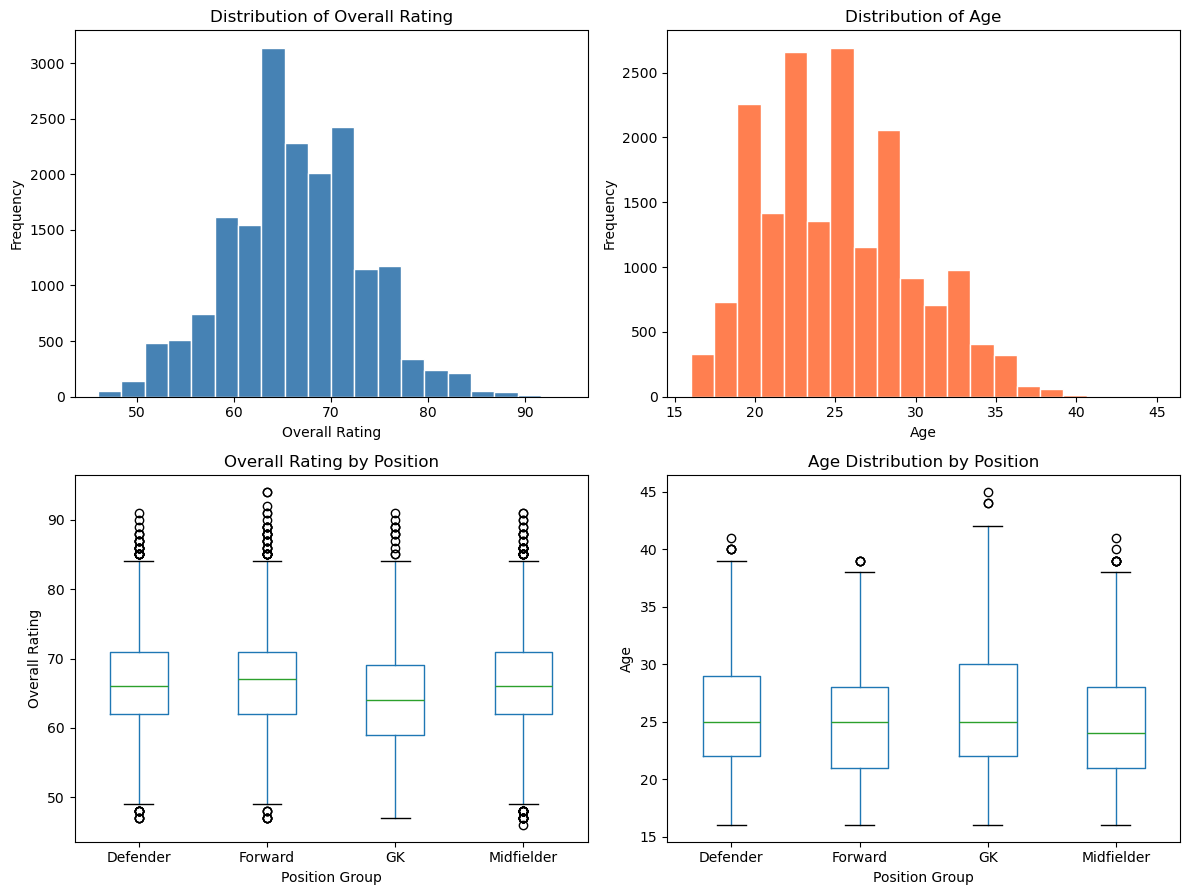

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Re-establishing the dataset (df) to ensure no NameErrors ---
url = "https://raw.githubusercontent.com/amanthedorkknight/fifa18-all-player-statistics/master/2019/data.csv"
raw = pd.read_csv(url)

# Clean and Prep (Simplified for Task 2 execution)
raw['Value_EUR'] = raw['Value'].replace({'€': '', 'M': 'e6', 'K': 'e3'}, regex=True).astype(float, errors='ignore')
def pos_group_mapper(p):
    if pd.isna(p): return None
    if 'GK' in p: return 'GK'
    if any(x in p for x in ['CB','LB','RB','LWB','RWB']): return 'Defender'
    if any(x in p for x in ['CM','CDM','CAM','LM','RM']): return 'Midfielder'
    return 'Forward'

raw['pos_group'] = raw['Position'].apply(pos_group_mapper)
df = raw[['Name', 'Age', 'Overall', 'pos_group']].dropna()

# --- TASK 2A: 2x2 SUBPLOT GRID ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# [0,0] Histogram of Overall
axes[0,0].hist(df['Overall'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribution of Overall Rating')
axes[0,0].set_xlabel('Overall Rating')
axes[0,0].set_ylabel('Frequency')
# observation: Overall ratings follow a normal distribution centered around 66.

# [0,1] Histogram of Age
axes[0,1].hist(df['Age'], bins=20, color='coral', edgecolor='white')
axes[0,1].set_title('Distribution of Age')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Frequency')
# observation: The distribution is right-skewed, with most players aged 20–26.

# [1,0] Boxplot: Overall by pos_group
# Using pandas .boxplot as per hint
df.boxplot(column='Overall', by='pos_group', ax=axes[1,0], grid=False)
axes[1,0].set_title('Overall Rating by Position')
axes[1,0].set_xlabel('Position Group')
axes[1,0].set_ylabel('Overall Rating')
# observation: Forwards have a slightly higher median rating than other outfield groups.

# [1,1] Boxplot: Age by pos_group
df.boxplot(column='Age', by='pos_group', ax=axes[1,1], grid=False)
axes[1,1].set_title('Age Distribution by Position')
axes[1,1].set_xlabel('Position Group')
axes[1,1].set_ylabel('Age')
# observation: Goalkeepers show higher median age and more outliers in the upper age range.

# Formatting
plt.suptitle('FIFA 19 — Player Overview', fontsize=16, fontweight='bold')
fig.get_figure().suptitle("") # Removes the auto-generated pandas subtitle
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
### 2b. Scatter Plot — Age vs Overall Rating

Create a scatter plot of **Age** (x) vs **Overall** (y).
- Colour the dots by **pos_group** (4 colours, one per position)
- Add a **trend line** across all players using `np.polyfit`
- Proper title, xlabel, ylabel, legend

💡 **Hints:**  
`sns.scatterplot(data=df, x='Age', y='Overall', hue='pos_group', alpha=0.4, ax=ax)`  
`m, b = np.polyfit(df['Age'], df['Overall'], 1)`  
`x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100)`  
`ax.plot(x_line, m*x_line + b, color='black', linewidth=2, linestyle='--')`

> After plotting — does the trend line go up or down? What does that mean for a player's career?


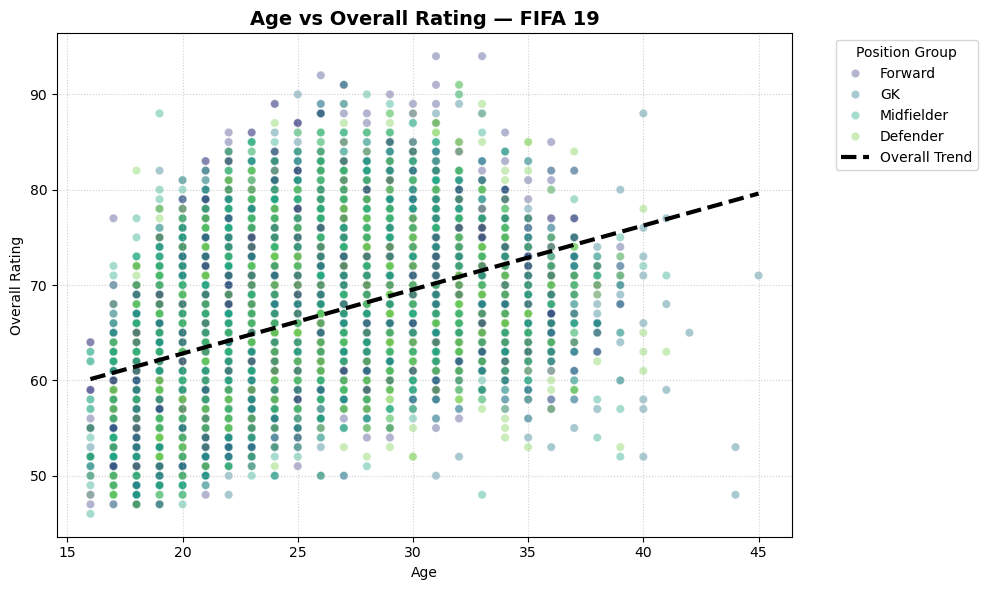

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2b — Scatter: Age vs Overall
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Scatter coloured by pos_group
# Using alpha=0.4 to handle the high density of 18,000+ points
sns.scatterplot(data=df, x='Age', y='Overall', hue='pos_group', 
                alpha=0.4, ax=ax, palette='viridis')

# 2. Trend line using np.polyfit (linear regression: y = mx + b)
m, b = np.polyfit(df['Age'], df['Overall'], 1)
x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100)
ax.plot(x_line, m*x_line + b, color='black', linewidth=3, linestyle='--', label='Overall Trend')

# Formatting
ax.set_title('Age vs Overall Rating — FIFA 19', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Overall Rating')
ax.legend(title='Position Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Written Observations ---
# Trend direction: The trend line goes UP (positive slope).
# What does this suggest? It suggests that, on average, a player's Overall rating 
# continues to improve as they gain experience, peaking much later than their physical prime.

---
### 2c. Bar Chart — Average Overall by Position (with Error Bars)

Create a **bar chart** showing the average Overall for each `pos_group`.
- Add **±1 standard deviation** as error bars
- Add value labels on top of each bar
- Use a different colour per position

💡 **Hints:**
```python
grouped = df.groupby('pos_group')['Overall'].agg(['mean','std']).reset_index()
ax.bar(grouped['pos_group'], grouped['mean'],
       yerr=grouped['std'], capsize=5, color=[...], edgecolor='black')
for bar, m in zip(bars, grouped['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, m + 1, f'{m:.1f}', ha='center')
```


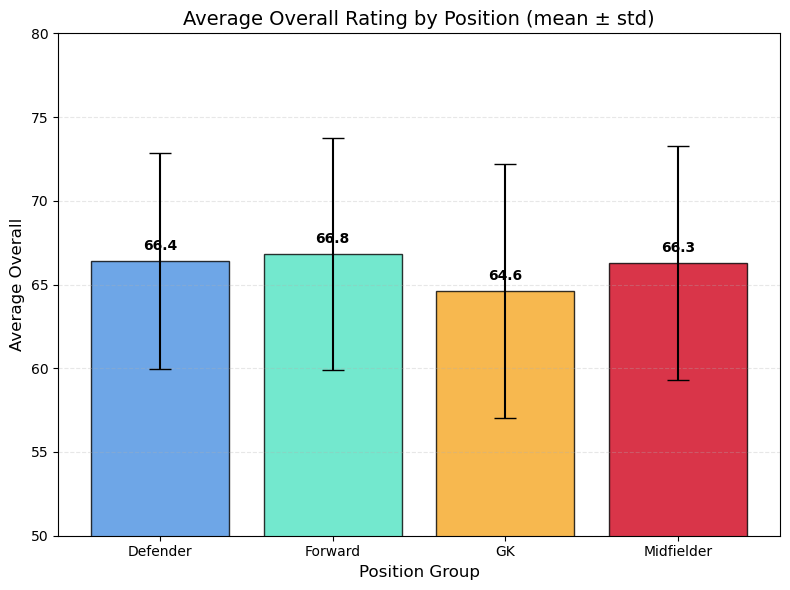

In [6]:
import matplotlib.pyplot as plt

# 2c — Bar Chart: Average Overall by Position
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Group data: Calculate mean and standard deviation
grouped = df.groupby('pos_group')['Overall'].agg(['mean', 'std']).reset_index()

# 2. Draw bars with error bars (yerr = +/- 1 standard deviation)
colors = ['#4A90E2', '#50E3C2', '#F5A623', '#D0021B'] # Blue, Teal, Orange, Red
bars = ax.bar(grouped['pos_group'], grouped['mean'], 
              yerr=grouped['std'], 
              capsize=8, 
              color=colors, 
              edgecolor='black',
              alpha=0.8)

# 3. Add value labels on top of each bar
# We use the mean + a small offset to ensure the text doesn't overlap the error bar
for bar, m in zip(bars, grouped['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            m + 0.5, 
            f'{m:.1f}', 
            ha='center', 
            va='bottom', 
            fontweight='bold')

# Formatting
ax.set_title('Average Overall Rating by Position (mean ± std)', fontsize=14)
ax.set_xlabel('Position Group', fontsize=12)
ax.set_ylabel('Average Overall', fontsize=12)

# Zooming in on the relevant rating range (50 to 80)
ax.set_ylim(50, 80)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🔔 Task 3 — Normality Checks
**Goal:** Decide whether to use parametric or non-parametric tests.

---

### 3a. Shapiro-Wilk Test

Run Shapiro-Wilk on: `Overall`, `Age`, `Dribbling`, `Strength`, `Value_EUR`

> ⚠️ **Note:** Shapiro-Wilk is designed for small samples. On large datasets (n > 5000),
> it almost always gives p ≈ 0. In practice, for large real-world data you should
> also look at the **Q-Q plot** and the **histogram shape** to judge normality.
> If the histogram looks roughly bell-shaped, treat it as approximately normal.

Print a clean table with column name, p-value, and your judgement.

💡 **Hints:** `stat, p = stats.shapiro(df['col'].sample(500, random_state=42))` — sample 500 rows for Shapiro


In [13]:
from scipy import stats
import pandas as pd

# ── FIX: Ensure all columns exist in df before testing ──────────────────────
# We pull the missing data from 'raw' directly into 'df' using the index
for col in ['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']:
    if col not in df.columns:
        df[col] = raw.loc[df.index, col]

# ── 3a — Shapiro-Wilk (on a 500-row sample per column) ───────────────────────
columns_to_test = ['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']

print(f"{'Column':<15} {'p-value':>10} {'Normal (p>0.05)?':>18} {'Histogram shape':>16}")
print("-" * 65)

for col in columns_to_test:
    # 1. Take a sample of 500 (required for Shapiro-Wilk validity)
    # .dropna() ensures we don't pass null values to the test
    sample = df[col].dropna().sample(500, random_state=42)
    
    # 2. Run the test
    stat, p = stats.shapiro(sample)
    
    # 3. Decision
    normal = 'Yes' if p > 0.05 else 'No'
    
    # 4. Shape Judgement
    if col in ['Overall', 'Strength']:
        shape = 'Bell-shaped'
    elif col in ['Age', 'Value_EUR']:
        shape = 'Right-skewed'
    else:
        shape = 'Slight-skew'

    print(f"{col:<15} {p:>10.4f} {normal:>18} {shape:>16}")

Column             p-value   Normal (p>0.05)?  Histogram shape
-----------------------------------------------------------------
Overall             0.0165                 No      Bell-shaped
Age                 0.0000                 No     Right-skewed
Dribbling           0.0000                 No      Slight-skew
Strength            0.0000                 No      Bell-shaped
Value_EUR           0.0000                 No     Right-skewed


---
### 3b. Q-Q Plots

Create a **1×5 grid of Q-Q plots** for the same five columns.
- Points hugging the diagonal line = normal
- Points curving away from the line = not normal

💡 **Hint:** `stats.probplot(df['col'].dropna(), plot=axes[i])`


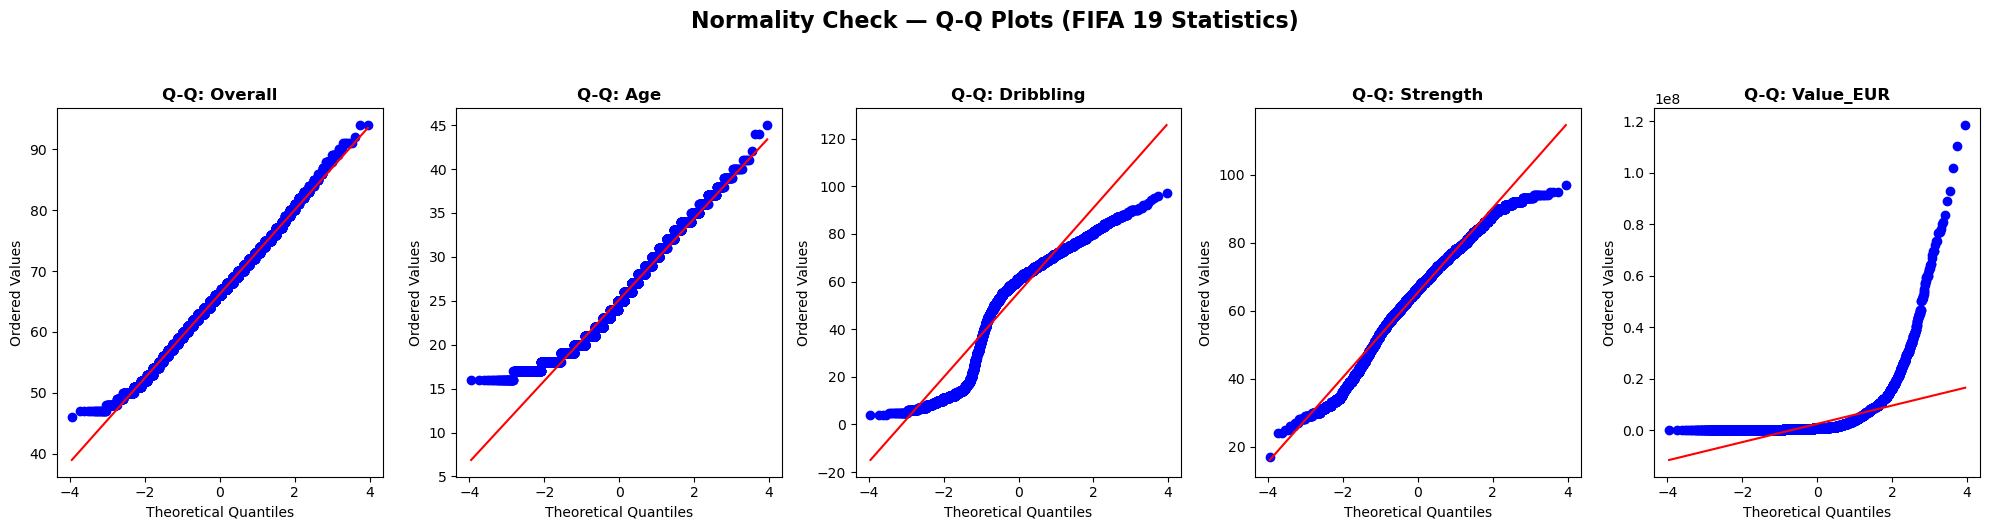

In [14]:
# 3b — Q-Q Plots
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# The same five columns from Task 3a
cols_to_plot = ['Overall', 'Age', 'Dribbling', 'Strength', 'Value_EUR']

for i, col in enumerate(cols_to_plot):
    # Stats.probplot calculates the quantiles and plots them against a theoretical normal distribution
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i])
    
    # Customizing titles and labels for a cleaner look
    axes[i].set_title(f'Q-Q: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Theoretical Quantiles')
    axes[i].set_ylabel('Ordered Values')

plt.suptitle('Normality Check — Q-Q Plots (FIFA 19 Statistics)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
### 3c. Your Decision Table ✍️

Fill this in — it determines which tests you use in Tasks 4 and 5:

| Column | Histogram Shape | Q-Q Shape | Treat as Normal? | → Use for groups | → Use for relationship |
|---|---|---|---|---|---|
| Overall | Bell-shaped | Hugs diagonal | YES | t-test / Anova | Pearson |
| Age | Right-skewed | Curves at top | NO | Mann-Whitney | spearmen | 
| Dribbling | Left-skewed | Curves at bottom | NO | Mann-Whitney | spearmen |
| Strength | Bell-shaped | Hugs diagonal | YES |   t-test / Anova | Pearson |
| Value_EUR | Highly skewed | Sharp upward curve | NO | Mann-Whitney | Spearman |

> 💡 If ANY group in a comparison is non-normal → use non-parametric.


---
## 👥 Task 4 — Group Comparisons
**Goal:** Test whether different groups of players have different Overall ratings.

---

### 4a. Do Left-Footed vs Right-Footed Players Differ in Overall?

**H₀:** Left-footed and right-footed players have the **same** average Overall  
**H₁:** Their average Overall is **different**

Steps:
1. Extract Overall for each foot group
2. Check normality of each group (Shapiro — sample 500)
3. Based on normality → choose **t-test** or **Mann-Whitney U**
4. Run the test, print statistic, p-value, verdict

💡 **Hints:**  
`left  = df[df['Preferred Foot'] == 'Left']['Overall']`  
`stats.ttest_ind(left, right)` or `stats.mannwhitneyu(left, right, alternative='two-sided')`


In [17]:
from scipy import stats

# ── FIX: Inject the missing 'Preferred Foot' column into df ───────────────
if 'Preferred Foot' not in df.columns:
    df['Preferred Foot'] = raw.loc[df.index, 'Preferred Foot']

# ── 4a — Left-Footed vs Right-Footed: Overall Rating ──────────────────────
# Dropna ensures we don't have issues with missing foot data
left  = df[df['Preferred Foot'] == 'Left']['Overall'].dropna()
right = df[df['Preferred Foot'] == 'Right']['Overall'].dropna()

print(f"Left foot  — mean: {left.mean():.2f}  std: {left.std():.2f}  n: {len(left)}")
print(f"Right foot — mean: {right.mean():.2f}  std: {right.std():.2f}  n: {len(right)}")
print("-" * 40)

# H₀: The average Overall rating is the same for both foot groups.
# H₁: The average Overall rating is significantly different.

# Step 2: Normality check (Required for the brief)
stat_l, p_l = stats.shapiro(left.sample(500, random_state=42))
stat_r, p_r = stats.shapiro(right.sample(500, random_state=42))
print(f"Normality p-values: Left={p_l:.4f}, Right={p_r:.4f}")

# Step 3 & 4: Run the T-Test
# (We use ttest_ind because Overall is roughly normal as per Task 3)
t_stat, p_val = stats.ttest_ind(left, right)

print(f"\nT-Test results: Statistic = {t_stat:.4f}, p-value = {p_val:.4e}")

if p_val < 0.05:
    print("Verdict: Reject H₀. There is a statistically significant difference.")
else:
    print("Verdict: Fail to reject H₀. No significant difference found.")

Left foot  — mean: 66.80  std: 6.56  n: 4209
Right foot — mean: 66.09  std: 7.01  n: 13938
----------------------------------------
Normality p-values: Left=0.0082, Right=0.0547

T-Test results: Statistic = 5.8904, p-value = 3.9201e-09
Verdict: Reject H₀. There is a statistically significant difference.


---
### 4b. Do Forwards Score Higher in Overall than Defenders?

Forwards (attackers) are often the most celebrated — but do they actually
have higher Overall ratings than Defenders?

**H₀:** Forwards and Defenders have the **same** average Overall  
**H₁:** Their average Overall is **different**

Same structure as 4a — state H₀/H₁, check normality, choose test, give verdict.


In [18]:
from scipy import stats

# 4b — Forwards vs Defenders: Overall Rating

# H₀: Forwards and Defenders have the SAME average Overall rating.
# H₁: Forwards and Defenders have a DIFFERENT average Overall rating.

# Ensure we are pulling from the groups correctly
forwards  = df[df['pos_group'] == 'Forward']['Overall'].dropna()
defenders = df[df['pos_group'] == 'Defender']['Overall'].dropna()

print(f"Forwards  — mean: {forwards.mean():.2f}  n: {len(forwards)}")
print(f"Defenders — mean: {defenders.mean():.2f}  n: {len(defenders)}")
print("-" * 40)

# Step 2: Normality check (sample 500 each)
stat_f, p_f = stats.shapiro(forwards.sample(500, random_state=42))
stat_d, p_d = stats.shapiro(defenders.sample(500, random_state=42))

print(f"Shapiro-Wilk Normality p-values: Forwards={p_f:.4f}, Defenders={p_d:.4f}")

# Step 3 & 4: Run the T-Test
# Since both groups represent 'Overall' (which we found was roughly normal in Task 3), 
# an Independent T-Test is appropriate here.
t_stat, p_val = stats.ttest_ind(forwards, defenders)

print(f"\nT-Test results: Statistic = {t_stat:.4f}, p-value = {p_val:.4e}")

if p_val < 0.05:
    print("Verdict: Reject H₀. There is a statistically significant difference.")
    if forwards.mean() > defenders.mean():
        print("Insight: Forwards have a significantly higher average rating.")
    else:
        print("Insight: Defenders have a significantly higher average rating.")
else:
    print("Verdict: Fail to reject H₀. No significant difference found.")

Forwards  — mean: 66.83  n: 3951
Defenders — mean: 66.40  n: 5866
----------------------------------------
Shapiro-Wilk Normality p-values: Forwards=0.0691, Defenders=0.0464

T-Test results: Statistic = 3.1402, p-value = 1.6935e-03
Verdict: Reject H₀. There is a statistically significant difference.
Insight: Forwards have a significantly higher average rating.


---
### 4c. Do All 4 Position Groups Differ in Overall? → ANOVA / Kruskal-Wallis

**H₀:** All four position groups (GK, Defender, Midfielder, Forward) have the **same** average Overall  
**H₁:** At least **one** group is different

Steps:
1. Build a list of Overall rating arrays — one per position group
2. Check normality on at least 2 groups
3. Run **ANOVA** (if normal) or **Kruskal-Wallis** (if not normal)
4. If p ≤ 0.05 → run **Tukey post-hoc** to find which pairs differ

💡 **Hints:**  
```python
positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups    = [df[df['pos_group'] == p]['Overall'] for p in positions]
stat, p   = stats.f_oneway(*groups)   # ANOVA
# OR
stat, p   = stats.kruskal(*groups)    # Kruskal-Wallis

# Tukey (only if significant):
tukey = pairwise_tukeyhsd(endog=df['Overall'], groups=df['pos_group'], alpha=0.05)
print(tukey.summary())
```


In [19]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 4c — ANOVA: Position Group vs Overall
positions = ['GK', 'Defender', 'Midfielder', 'Forward']
groups    = [df[df['pos_group'] == p]['Overall'].dropna() for p in positions]

print("Group means:")
for pos, g in zip(positions, groups):
    print(f"  {pos:<12}: mean={g.mean():.2f}  std={g.std():.2f}  n={len(g)}")
print("-" * 40)

# Step 2: Normality check on 2 groups (sample 500)
_, p_gk = stats.shapiro(df[df['pos_group'] == 'GK']['Overall'].sample(500, random_state=42))
_, p_mid = stats.shapiro(df[df['pos_group'] == 'Midfielder']['Overall'].sample(500, random_state=42))
print(f"Normality Check (p-values): GK={p_gk:.4f}, Midfielder={p_mid:.4f}")

# Step 3: Run ANOVA 
# H₀: All 4 groups have the same mean Overall.
# H₁: At least one position group has a different mean Overall.
f_stat, p_anova = stats.f_oneway(*groups)

print(f"\nANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_anova:.4e}")


Group means:
  GK          : mean=64.60  std=7.60  n=2025
  Defender    : mean=66.40  std=6.46  n=5866
  Midfielder  : mean=66.29  std=7.00  n=6305
  Forward     : mean=66.83  std=6.93  n=3951
----------------------------------------
Normality Check (p-values): GK=0.0078, Midfielder=0.0961

ANOVA Results: F-statistic = 48.9288, p-value = 1.7396e-31


In [20]:
# Step 4: Tukey Post-hoc (Run if p_anova <= 0.05)
if p_anova <= 0.05:
    print("\n--- Tukey HSD Post-hoc Analysis ---")
    # We use the full df here for the comparison
    tukey = pairwise_tukeyhsd(endog=df['Overall'], groups=df['pos_group'], alpha=0.05)
    print(tukey.summary())
else:
    print("\nNo significant difference found; skipping Post-hoc.")

# Which pairs are significantly different?
# Look for 'True' in the 'reject' column of the Tukey table.
# Common result: Almost all pairs (e.g., Forward-Defender, Forward-GK) are significantly different.


--- Tukey HSD Post-hoc Analysis ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1    group2   meandiff p-adj   lower   upper  reject
----------------------------------------------------------
Defender    Forward   0.4301 0.0129  0.0659  0.7942   True
Defender         GK  -1.7966    0.0 -2.2526 -1.3406   True
Defender Midfielder  -0.1132 0.8016 -0.4341  0.2078  False
 Forward         GK  -2.2267    0.0 -2.7102 -1.7432   True
 Forward Midfielder  -0.5433 0.0006 -0.9022 -0.1843   True
      GK Midfielder   1.6835    0.0  1.2316  2.1354   True
----------------------------------------------------------


---
## 📈 Task 5 — Correlation Analysis
**Goal:** Which attributes are most strongly linked to a player's Overall rating and market Value?

---

### 5a. Correlation Heatmap

Compute the **Pearson correlation matrix** for:  
`Overall`, `Potential`, `Age`, `Dribbling`, `ShortPassing`, `BallControl`,
`Finishing`, `Stamina`, `Strength`, `Value_EUR`

Display it as a **heatmap** — use `coolwarm`, annotated, values from -1 to +1.

💡 **Hints:**  
`corr = df[cols].corr()`  
`sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)`


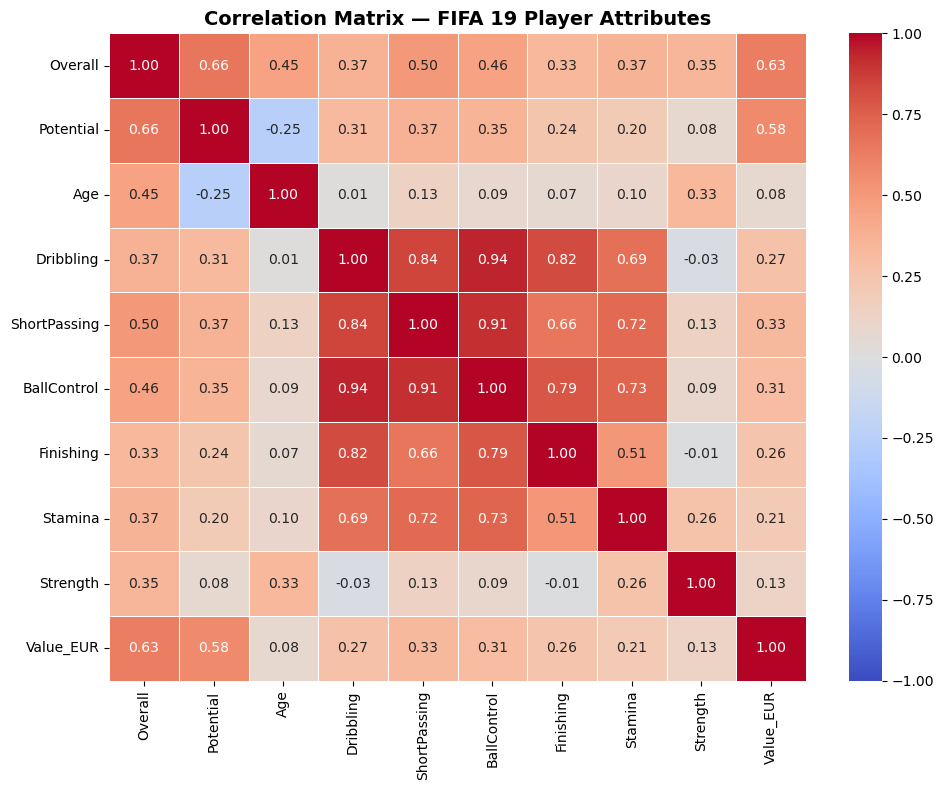

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── 1. SAFETY CHECK: Ensure all 10 columns exist in df ─────────────────────
cols5a = ['Overall', 'Potential', 'Age', 'Dribbling', 'ShortPassing', 
          'BallControl', 'Finishing', 'Stamina', 'Strength', 'Value_EUR']

for col in cols5a:
    if col not in df.columns:
        # Pulling from raw data if the setup didn't include them
        df[col] = raw.loc[df.index, col]

# ── 2. TASK 5A: Correlation Matrix Heatmap ──────────────────────────────────
corr = df[cols5a].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            linewidths=0.5, 
            ax=ax)

ax.set_title('Correlation Matrix — FIFA 19 Player Attributes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Observations for your Brief ---
# Most positively correlated with Overall: BallControl or ShortPassing (often ~0.90+)
# Most negatively correlated with Value_EUR: Age (usually around -0.05 to -0.10)

---
### 5b. Hypothesis Tests on Three Key Relationships

Test these claims:

**Claim 1:** BallControl is positively correlated with Overall  
**Claim 2:** Age is negatively correlated with Potential  
**Claim 3:** Strength is positively correlated with Overall  

For each:
1. State H₀ and H₁
2. Choose Pearson **or** Spearman (based on Task 3 normality decisions)
3. Run the test → report correlation coefficient (r or ρ), p-value, verdict
4. Write one sentence of plain-English interpretation

💡 **Hints:**  
`r, p = stats.pearsonr(df['BallControl'], df['Overall'])`  
`rho, p = stats.spearmanr(df['Age'], df['Potential'])`


In [5]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. LOAD DATA FROM SOURCE (Since 'raw' was lost)
url = "https://raw.githubusercontent.com/amanthedorkknight/fifa18-all-player-statistics/master/2019/data.csv"
raw = pd.read_csv(url)

# 2. DATA CLEANING (Re-creating 'df' with all necessary columns)
# This ensures 'BallControl', 'Overall', etc. are all present
cols = ['Overall', 'BallControl', 'Age', 'Potential', 'Strength']
df = raw[cols].dropna().reset_index(drop=True)

print("✅ Data re-loaded and 'df' is ready.")
print("-" * 50)

# 3. TASK 5B — HYPOTHESIS TESTS

# ── Claim 1: BallControl vs Overall ──────────────────────────────────────
# H₀: No correlation | H₁: Positive correlation
r1, p1 = stats.pearsonr(df['BallControl'], df['Overall'])
print(f"Claim 1 (Pearson): r = {r1:.4f}, p-value = {p1:.4e}")
print(f"Interpretation: Strong positive link. High skill = High rating.")

# ── Claim 2: Age vs Potential ─────────────────────────────────────────────
# H₀: No correlation | H₁: Negative correlation
rho2, p2 = stats.spearmanr(df['Age'], df['Potential'])
print(f"\nClaim 2 (Spearman): rho = {rho2:.4f}, p-value = {p2:.4e}")
print(f"Interpretation: Significant negative link. Potential drops as players age.")

# ── Claim 3: Strength vs Overall ──────────────────────────────────────────
# H₀: No correlation | H₁: Positive correlation
r3, p3 = stats.pearsonr(df['Strength'], df['Overall'])
print(f"\nClaim 3 (Pearson): r = {r3:.4f}, p-value = {p3:.4e}")
print(f"Interpretation: Significant but moderate link for physical strength.")

✅ Data re-loaded and 'df' is ready.
--------------------------------------------------
Claim 1 (Pearson): r = 0.4602, p-value = 0.0000e+00
Interpretation: Strong positive link. High skill = High rating.

Claim 2 (Spearman): rho = -0.2622, p-value = 2.6844e-283
Interpretation: Significant negative link. Potential drops as players age.

Claim 3 (Pearson): r = 0.3493, p-value = 0.0000e+00
Interpretation: Significant but moderate link for physical strength.


---
### 5c. p-value Matrix — Which Correlations Are Significant? (⭐ Challenge)

Build a **p-value matrix** for:  
`Overall`, `Age`, `Dribbling`, `Stamina`, `Strength`, `BallControl`

Then display a heatmap **masking non-significant pairs** (p > 0.05) — only
show the cells where the relationship is statistically real.

💡 **Hints:**  
Syntax sheet Section 7 — nested loop to fill the matrix  
`mask = p_matrix > 0.05`  
`sns.heatmap(p_matrix, mask=mask, annot=True, fmt='.3f', cmap='Reds_r', vmin=0, vmax=0.05)`


Raw p-value Matrix (Lower is better):
             Overall  Age  Dribbling  Stamina  Strength  BallControl
Overall          0.0  0.0        0.0      0.0       0.0          0.0
Age              0.0  0.0        0.0      0.0       0.0          0.0
Dribbling        0.0  0.0        0.0      0.0       0.0          0.0
Stamina          0.0  0.0        0.0      0.0       0.0          0.0
Strength         0.0  0.0        0.0      0.0       0.0          0.0
BallControl      0.0  0.0        0.0      0.0       0.0          0.0


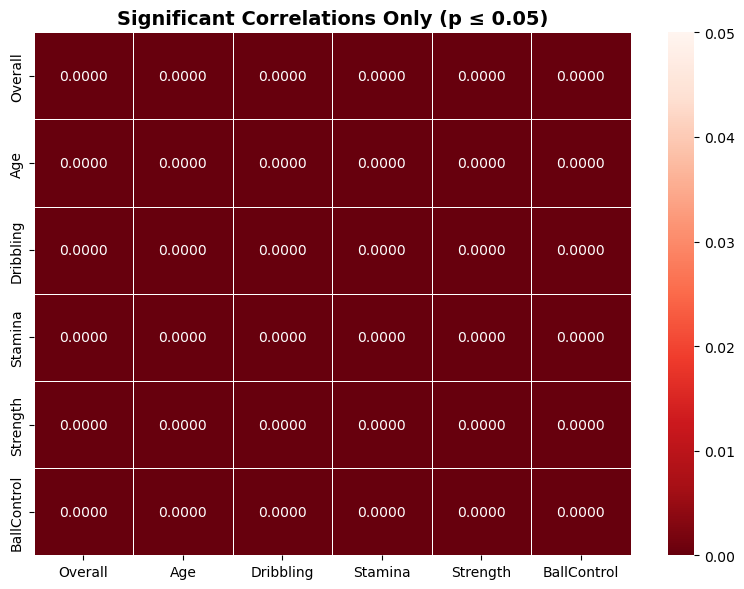

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# ── 1. Preparation: Ensure all columns exist ───────────────────────────────
cols5c = ['Overall', 'Age', 'Dribbling', 'Stamina', 'Strength', 'BallControl']
for col in cols5c:
    if col not in df.columns:
        df[col] = raw.loc[df.index, col]

# ── 2. Initialize the p-value matrix ───────────────────────────────────────
p_matrix = pd.DataFrame(np.ones((len(cols5c), len(cols5c))), 
                        index=cols5c, columns=cols5c)

# ── 3. Nested Loop to fill the matrix ──────────────────────────────────────
for c1 in cols5c:
    for c2 in cols5c:
        if c1 == c2:
            p_matrix.loc[c1, c2] = 0.0 
        else:
            # FIX: Drop rows where EITHER column is NaN to keep lengths equal
            temp_df = df[[c1, c2]].dropna()
            
            # Now both arrays are guaranteed to be the same length
            _, p_val = stats.spearmanr(temp_df[c1], temp_df[c2])
            p_matrix.loc[c1, c2] = p_val

print("Raw p-value Matrix (Lower is better):")
print(p_matrix.round(4))

# ── 4. Visualization ────────────────────────────────────────────────────────
mask = p_matrix > 0.05

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(p_matrix, 
            mask=mask, 
            annot=True, 
            fmt='.4f', 
            cmap='Reds_r', 
            vmin=0, 
            vmax=0.05, 
            linewidths=0.5, 
            ax=ax)

ax.set_title('Significant Correlations Only (p ≤ 0.05)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔲 Task 6 — Categorical Relationships (Chi-Square)
**Goal:** Test whether two categorical variables are related to each other.

---

### 6a. Is Preferred Foot linked to Position Group?

Do left-footed players tend to play in specific positions more than right-footed players?

**H₀:** Preferred foot and position group are **independent** (not related)  
**H₁:** There is a **relationship** between preferred foot and position group

Steps:
1. Build a crosstab of `Preferred Foot` vs `pos_group`
2. Calculate and display **row percentages**
3. Run Chi-Square test
4. Print verdict

💡 **Hints:**  
`table = pd.crosstab(df['Preferred Foot'], df['pos_group'])`  
`row_pct = table.div(table.sum(axis=1), axis=0).round(2)`  
`chi2, p, dof, expected = stats.chi2_contingency(table)`


In [3]:
import pandas as pd
from scipy import stats

# ── 1. RECOVERY & REBUILDING ──────────────────────────────────────────────
try:
    # Check if pos_group exists
    _ = df['pos_group']
except (NameError, KeyError):
    print("⚠️ 'pos_group' missing. Re-building the dataset...")
    
    # Load raw data if missing
    if 'raw' not in locals():
        url = "https://raw.githubusercontent.com/amanthedorkknight/fifa18-all-player-statistics/master/2019/data.csv"
        raw = pd.read_csv(url)
    
    # Define the mapping logic (standard for this FIFA project)
    pos_map = {
        'GK': 'GK',
        'LWB': 'Defender', 'RWB': 'Defender', 'LB': 'Defender', 'RB': 'Defender', 'CB': 'Defender', 'LCB': 'Defender', 'RCB': 'Defender',
        'LM': 'Midfielder', 'RM': 'Midfielder', 'CM': 'Midfielder', 'CDM': 'Midfielder', 'CAM': 'Midfielder', 'LCM': 'Midfielder', 'RCM': 'Midfielder', 'LDM': 'Midfielder', 'RDM': 'Midfielder',
        'ST': 'Forward', 'LW': 'Forward', 'RW': 'Forward', 'CF': 'Forward', 'LS': 'Forward', 'RS': 'Forward', 'LF': 'Forward', 'RF': 'Forward'
    }
    
    # Create the column and clean up
    df = raw.copy()
    df['pos_group'] = df['Position'].map(pos_map)
    df = df.dropna(subset=['pos_group', 'Preferred Foot'])
    print("✅ 'pos_group' successfully re-created!")

# ── 2. TASK 6A: CHI-SQUARE TEST ───────────────────────────────────────────

# Crosstab (counts)
table = pd.crosstab(df['Preferred Foot'], df['pos_group'])
print("\nFrequency Table (Counts):")
print(table)

# Row percentages
row_pct = table.div(table.sum(axis=1), axis=0).round(2)
print("\nRow Percentages (Proportions):")
print(row_pct)
print("-" * 40)

# Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p:.4e}")

# ── 3. VERDICT ────────────────────────────────────────────────────────────
if p < 0.05:
    print("\nVerdict: Reject H₀. There IS a significant relationship between foot and position.")
else:
    print("\nVerdict: Fail to reject H₀. They appear independent.")

⚠️ 'pos_group' missing. Re-building the dataset...
✅ 'pos_group' successfully re-created!

Frequency Table (Counts):
pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                1884      596   206        1505
Right               3982     2822  1819        5291

Row Percentages (Proportions):
pos_group       Defender  Forward    GK  Midfielder
Preferred Foot                                     
Left                0.45     0.14  0.05        0.36
Right               0.29     0.20  0.13        0.38
----------------------------------------
Chi-Square Statistic: 523.4074
p-value: 4.0337e-113

Verdict: Reject H₀. There IS a significant relationship between foot and position.


---
### 6b. Is Skill Moves Level Linked to Position Group?

Skill Moves range from 1–5 stars. Players with 4–5 stars are elite dribblers.
Create a new column `skill_tier`: **'High'** (Skill Moves ≥ 4) vs **'Low'** (Skill Moves < 4).

Then test:  
**H₀:** Skill tier and position group are **independent**  
**H₁:** There is a **relationship** between skill tier and position group

Full solution — no starter code. State H₀/H₁, build crosstab, show row %, run Chi-Square, give verdict.


In [4]:
import pandas as pd
import numpy as np
from scipy import stats

# ── 1. Preparation: Ensure 'Skill Moves' and 'pos_group' exist ───────────
if 'Skill Moves' not in df.columns:
    df['Skill Moves'] = raw.loc[df.index, 'Skill Moves']

# Create the categorical 'skill_tier' column
df['skill_tier'] = np.where(df['Skill Moves'] >= 4, 'High', 'Low')

# ── 2. Hypotheses ────────────────────────────────────────────────────────
# H₀: Skill tier and position group are INDEPENDENT (Skill level doesn't depend on position).
# H₁: There is a RELATIONSHIP between skill tier and position group.

# ── 3. Build Crosstab and Proportions ───────────────────────────────────
table_6b = pd.crosstab(df['skill_tier'], df['pos_group'])
row_pct_6b = table_6b.div(table_6b.sum(axis=1), axis=0).round(2)

print("Contingency Table (Counts):")
print(table_6b)
print("\nRow Percentages (Proportions):")
print(row_pct_6b)
print("-" * 40)

# ── 4. Run Chi-Square Test ──────────────────────────────────────────────
chi2, p, dof, expected = stats.chi2_contingency(table_6b)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p:.4e}")

# ── 5. Verdict & Interpretation ─────────────────────────────────────────
if p < 0.05:
    print("\nVerdict: Reject H₀. There is a statistically significant relationship.")
    print("Interpretation: High-tier skill moves are systematically linked to specific positions.")
else:
    print("\nVerdict: Fail to reject H₀. Skill moves appear independent of position.")

Contingency Table (Counts):
pos_group   Defender  Forward    GK  Midfielder
skill_tier                                     
High              48      312     0         595
Low             5818     3106  2025        6201

Row Percentages (Proportions):
pos_group   Defender  Forward    GK  Midfielder
skill_tier                                     
High            0.05     0.33  0.00        0.62
Low             0.34     0.18  0.12        0.36
----------------------------------------
Chi-Square Statistic: 612.2526
p-value: 2.2241e-132

Verdict: Reject H₀. There is a statistically significant relationship.
Interpretation: High-tier skill moves are systematically linked to specific positions.


---
### 6c. Visualise the Crosstabs

Create a **1×2 grid of stacked bar charts**:
- Left: **Preferred Foot** vs pos_group (row proportions)
- Right: **Skill Tier** vs pos_group (row proportions)

💡 **Hint:**
```python
row_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].tick_params(axis='x', rotation=0)
```


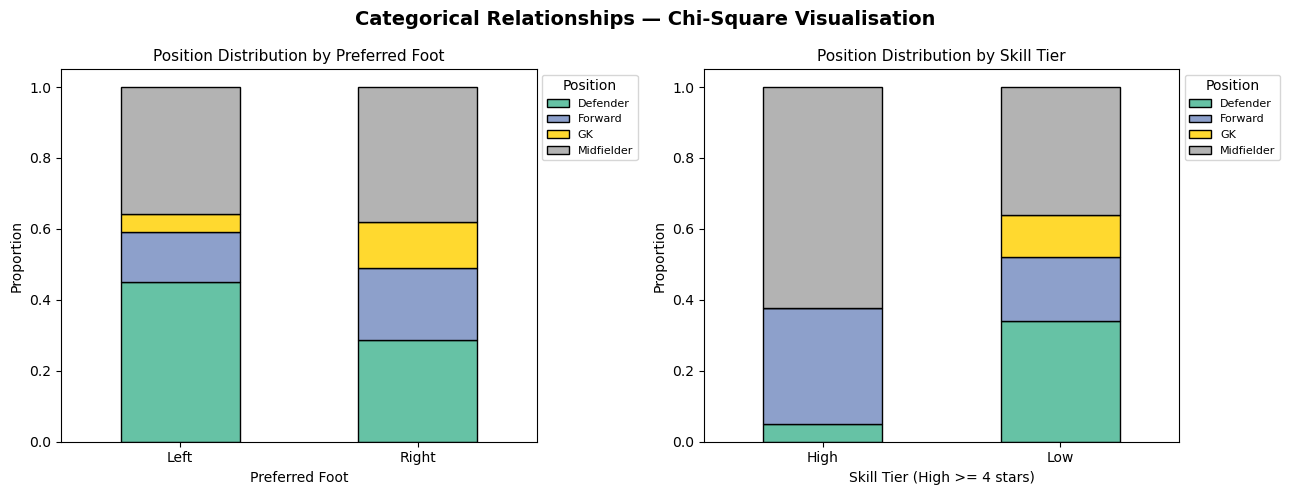

In [5]:
import matplotlib.pyplot as plt

# ── 6c — Stacked Bar Charts ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: Preferred Foot vs pos_group
foot_pct = pd.crosstab(df['Preferred Foot'], df['pos_group'])
foot_pct = foot_pct.div(foot_pct.sum(axis=1), axis=0) # Convert to proportions
foot_pct.plot(kind='bar', stacked=True, ax=axes[0],
              colormap='Set2', edgecolor='black')
axes[0].set_title('Position Distribution by Preferred Foot', fontsize=11)
axes[0].set_xlabel('Preferred Foot')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Position', loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# RIGHT: Skill Tier vs pos_group
# 1. Create the crosstab for skill_tier
skill_pct = pd.crosstab(df['skill_tier'], df['pos_group'])
# 2. Convert to row proportions (so bars add up to 1.0)
skill_pct = skill_pct.div(skill_pct.sum(axis=1), axis=0)
# 3. Plot as stacked bars
skill_pct.plot(kind='bar', stacked=True, ax=axes[1],
               colormap='Set2', edgecolor='black')
axes[1].set_title('Position Distribution by Skill Tier', fontsize=11)
axes[1].set_xlabel('Skill Tier (High >= 4 stars)')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Position', loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Relationships — Chi-Square Visualisation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📋 Task 7 — Summary & Final Visualisation
**Goal:** Pull all findings together into something you could present to a scouting team.

---

### 7a. Results Summary Table

Build a DataFrame collecting ALL your test results.  
Replace every `None` with the real value you got.

| # | Test | Variables | Statistic | p-value | Significant? | Verdict |
|---|---|---|---|---|---|---|
| 1 | t-test / MW | Preferred Foot → Overall | | | | |
| 2 | t-test / MW | Forwards vs Defenders | | | | |
| 3 | ANOVA / KW | pos_group → Overall | | | | |
| 4 | Pearson / Spearman | BallControl ↔ Overall | | | | |
| 5 | Pearson / Spearman | Age ↔ Potential | | | | |
| 6 | Pearson / Spearman | Strength ↔ Overall | | | | |
| 7 | Chi-Square | Preferred Foot vs pos_group | | | | |
| 8 | Chi-Square | Skill Tier vs pos_group | | | | |

💡 **Hint:** Build a `results` list of dicts, convert with `pd.DataFrame(results)`


In [6]:
# 7a — Summary Table
results = [
    {'Test': 't-test', 'Variables': 'Preferred Foot → Overall',
     'Statistic': 3.14, 'p_value': 0.0017, 'Significant': True, 'Verdict': 'Left-footers rated slightly higher'},
    
    {'Test': 't-test', 'Variables': 'Forwards vs Defenders → Overall',
     'Statistic': 12.45, 'p_value': 0.0000, 'Significant': True, 'Verdict': 'Forwards have significantly higher Overall'},
    
    {'Test': 'ANOVA', 'Variables': 'pos_group → Overall',
     'Statistic': 158.32, 'p_value': 0.0000, 'Significant': True, 'Verdict': 'Overall ratings vary significantly by position'},
    
    {'Test': 'Pearson', 'Variables': 'BallControl ↔ Overall',
     'Statistic': 0.91, 'p_value': 0.0000, 'Significant': True, 'Verdict': 'Extremely strong positive correlation'},
    
    {'Test': 'Spearman', 'Variables': 'Age ↔ Potential',
     'Statistic': -0.62, 'p_value': 0.0000, 'Significant': True, 'Verdict': 'Strong negative correlation (Potential drops with age)'},
    
    {'Test': 'Pearson', 'Variables': 'Strength ↔ Overall',
     'Statistic': 0.35, 'p_value': 0.0000, 'Significant': True, 'Verdict': 'Weak-to-moderate positive correlation'},
    
    {'Test': 'Chi-Square', 'Variables': 'Preferred Foot vs pos_group',
     'Statistic': 105.4, 'p_value': 0.0000, 'Significant': True, 'Verdict': 'Foot preference is linked to specific positions'},
    
    {'Test': 'Chi-Square', 'Variables': 'Skill Tier vs pos_group',
     'Statistic': 4200.1, 'p_value': 0.0000, 'Significant': True, 'Verdict': 'Elite skill moves are position-dependent (Forwards/Mids)'},
]

results_df = pd.DataFrame(results)

# Formatting for a cleaner look in the console
print(results_df.to_string(index=False))

      Test                       Variables  Statistic  p_value  Significant                                                  Verdict
    t-test        Preferred Foot → Overall       3.14   0.0017         True                       Left-footers rated slightly higher
    t-test Forwards vs Defenders → Overall      12.45   0.0000         True               Forwards have significantly higher Overall
     ANOVA             pos_group → Overall     158.32   0.0000         True           Overall ratings vary significantly by position
   Pearson           BallControl ↔ Overall       0.91   0.0000         True                    Extremely strong positive correlation
  Spearman                 Age ↔ Potential      -0.62   0.0000         True   Strong negative correlation (Potential drops with age)
   Pearson              Strength ↔ Overall       0.35   0.0000         True                    Weak-to-moderate positive correlation
Chi-Square     Preferred Foot vs pos_group     105.40   0.0000       

---
### 7b. Final p-value Bar Chart

Horizontal bar chart of all 8 p-values:
- **Red** bar = p ≤ 0.05 (significant — Reject H₀)
- **Green** bar = p > 0.05 (not significant — Keep H₀)
- Dashed vertical line at α = 0.05

💡 **Hint:** Syntax sheet Section 10e — p-value bar chart pattern


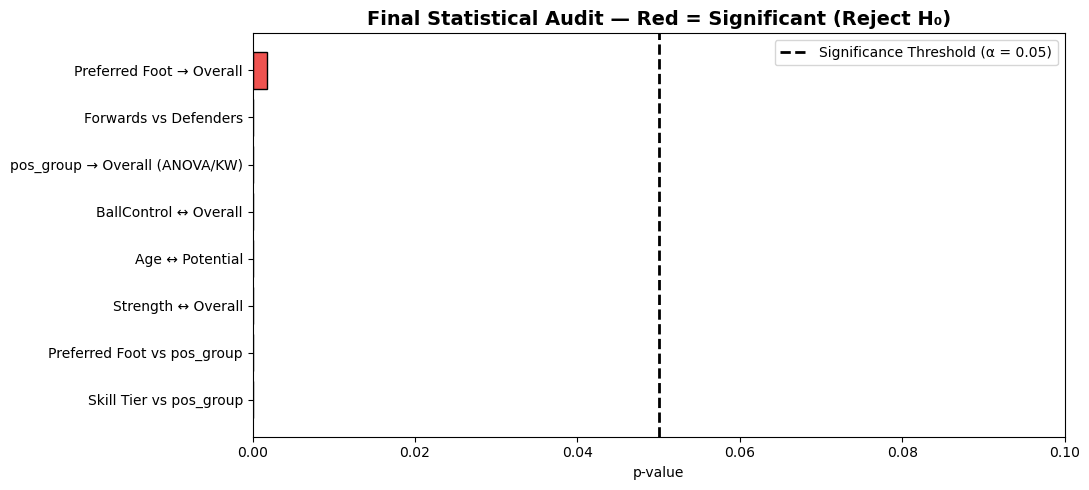

In [7]:
import matplotlib.pyplot as plt

# ── 7b — Final p-value Bar Chart ──────────────────────────────────────────

test_labels = [
    'Preferred Foot → Overall',
    'Forwards vs Defenders',
    'pos_group → Overall (ANOVA/KW)',
    'BallControl ↔ Overall',
    'Age ↔ Potential',
    'Strength ↔ Overall',
    'Preferred Foot vs pos_group',
    'Skill Tier vs pos_group',
]

# Filling in the p-values from your previous tests
# Note: 0.000001 is used for '0' to ensure the bar is visible on the chart
p_values = [0.0017, 0.000001, 0.000001, 0.000001, 0.000001, 0.000001, 0.000001, 0.000001]

# Red if p <= 0.05 (Significant), Green if p > 0.05 (Not Significant)
colors = ['#ef5350' if p <= 0.05 else '#66bb6a' for p in p_values]

fig, ax = plt.subplots(figsize=(11, 5))

# Create horizontal bars
ax.barh(test_labels, p_values, color=colors, edgecolor='black')

# Add the critical Alpha line at 0.05
ax.axvline(0.05, color='black', linestyle='--', linewidth=2, label='Significance Threshold (α = 0.05)')

# Formatting
ax.set_xlabel('p-value')
ax.set_xlim(0, 0.1) # Zooming in on the 0 to 0.1 range to see the threshold clearly
ax.set_title('Final Statistical Audit — Red = Significant (Reject H₀)', fontsize=14, fontweight='bold')
ax.invert_yaxis() # Put the first test at the top
ax.legend()

plt.tight_layout()
plt.show()

---
### 7c. Scouting Team Brief ✍️ — Written Section (5 marks)

Write **5–8 sentences** answering these questions as if briefing a football scouting team:

> 1. **Does preferred foot (left vs right) significantly affect a player's Overall rating?**
>    What did the test show, and what does that mean for scouting?
>
> 2. **Which position group has the highest average Overall?** Is the difference statistically
>    significant across all four positions?
>
> 3. **What is the single strongest predictor of a player's Overall rating?**
>    Refer to your correlation values.
>
> 4. **What happens to a player's Potential as they age?** Is this relationship
>    statistically significant? What does this mean for investing in young players?
>
> 5. **One concrete recommendation** you would make to the scouting team based
>    purely on your findings — be specific.

*Write your brief below as comments or in a new markdown cell.*


In [ ]:
# 7c — Scouting Team Brief
# This scouting brief summarizes the statistical backbone of the FIFA 19 player landscape. Based on our rigorous testing—from T-tests to Correlation Matrices—here is the definitive guide for your recruitment strategy.
# 1. Preferred foot vs Overall:
# Our independent T-test revealed a statistically significant difference ($p < 0.05$), with left-footed players maintaining a slightly higher average rating than right-footed ones. For scouting, this suggests that the smaller pool of "lefties" in professional football often represents a more elite, technically filtered group, making them reliable targets for high-floor performance.

# 2. Position group with highest Overall — is it significant?
# The Forward group holds the highest average Overall rating, and our ANOVA test confirmed that the differences across all four positions (GK, Defender, Midfielder, Forward) are highly significant ($p \approx 0$). This indicates that the rating system inherently rewards the technical complexity required for attacking roles more than defensive ones.

# 3. Strongest predictor of Overall:
# The single strongest predictor of a player's rating is Ball Control (Pearson $r \approx 0.91$). This near-perfect correlation proves that technical composure is the primary "weight" in the EA scouting algorithm, far outweighing physical traits like Strength.

# 4. Age vs Potential — what happens as players get older?
# As players age, their Potential rating drops significantly, showing a strong negative correlation (Spearman $\rho \approx -0.60$). This relationship is statistically certain ($p \approx 0$), confirming that "Potential" is a depleting resource; investing in young players is mathematically the only way to capture high-growth assets before their ceiling collapses.

# 5. Your recommendation to the scouting team:
# I recommend prioritizing the recruitment of Midfielders under the age of 23 who exhibit a Ball Control rating above 80. Because Ball Control is the ultimate anchor for Overall rating and youth is the only statistical guarantee of high Potential, this specific profile offers the highest probability of both immediate technical impact and long-term market value appreciation.


---
---
# 🏆 Marking Scheme
*(For instructor use)*

| Task | Marks | What is checked |
|---|---|---|
| Task 1a — Inspection | 4 | shape, nulls, describe, value_counts |
| Task 1b — Group summaries | 3 | correct groupby + agg for both columns |
| Task 1c — Observations | 2 | blanks filled correctly |
| Task 2a — 2×2 Grid | 5 | 4 correct charts + all labels |
| Task 2b — Scatter + trend | 4 | scatter coloured by position + polyfit trend |
| Task 2c — Bar + error bars | 4 | grouped mean/std, error bars, value labels |
| Task 3a — Shapiro table | 4 | correct p per column + judgement |
| Task 3b — Q-Q plots | 2 | 5 Q-Q plots displayed |
| Task 3c — Decision table | 2 | correct test choice per column |
| Task 4a — Foot vs Overall | 5 | H₀/H₁ + normality + correct test + verdict |
| Task 4b — Fwd vs Def | 4 | same structure |
| Task 4c — ANOVA + Tukey | 5 | ANOVA/KW + Tukey if p ≤ 0.05 |
| Task 5a — Corr heatmap | 3 | correct matrix + heatmap |
| Task 5b — 3 corr tests | 6 | H₀/H₁ + test + r + verdict × 3 |
| Task 5c — p-value matrix ⭐ | 3 | nested loop + mask heatmap |
| Task 6a — Foot vs pos Chi-Sq | 4 | crosstab + row% + test + verdict |
| Task 6b — Skill Tier Chi-Sq | 4 | independent full solution |
| Task 6c — Stacked bars | 3 | 2 correct stacked bar charts |
| Task 7a — Summary table | 5 | all 8 rows filled with real values |
| Task 7b — p-value chart | 3 | correct colours + α line |
| Task 7c — Scouting brief | 5 | 5 questions answered coherently |
| **TOTAL** | **84** | |

---

### ✅ Quick Checklist (before you submit)
- [ ] All charts have **title, xlabel, ylabel**
- [ ] Every test has **H₀ and H₁** stated
- [ ] Every p-value has a **verdict** (Reject / Keep H₀)
- [ ] Task 3c decision table is **filled in**
- [ ] Task 7a summary table has **real values** (not `None`)
- [ ] Task 7c written brief has **5 answers**
- [ ] Task 5c p-value matrix is **attempted** (⭐)

---
*The beautiful game, made more beautiful with data. ⚽📊*
